In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import pingouin as pg
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib.lines import Line2D
import matplotlib.lines as mlines
import math
import seaborn as sns
import pickle
import h5py
import heapq
import maskdb_parsing as maskdb
from sklearn.decomposition import PCA
from scipy.stats import norm
from matplotlib import gridspec

## Selective Breeding analysis

## step 1. read input files

In [7]:
df_behavior = pd.read_excel('/Users/jialexu/Desktop/Project4SelectiveBreeding/experiment/SDA_VDA_selection/data/SB_summary_v2.xlsx', sheet_name='example_vda')
df_behavior = df_behavior.set_index('Fish_id')

In [9]:
wdir = '/Users/jialexu/Desktop/Project4SelectiveBreeding/experiment/LD_behavior_test/'
file_list = []
for file in os.listdir(wdir):
    if file in df_behavior.index.str[:8].unique():
        file_list+=(os.listdir(wdir+file+'/'))

arenafiles = []
binfiles = []
zonefiles = []
for file in file_list:
    if file.startswith('Arena'):
        arenafiles.append(file)
    elif file.startswith('Bin'):
        binfiles.append(file)
    elif file.startswith('Zone'):
        zonefiles.append(file)

In [11]:
arena_dfs = []
arena_dfs_1 = []
for file in arenafiles:
    date = file.split('-')[-1].split('.')[0]
    df = pd.read_excel(wdir+date+'/'+file)
    df['date'] = date
    if df.iloc[0,0] != 'Result 1':
        print(date)
        df.columns = df.iloc[1,:]
        df.rename(columns = {df.columns[-1]:'date'},inplace=True)
        arena_dfs_1.append(df.iloc[3:,:].reset_index())
    else:
        
        arena_dfs.append(df)
df_arena_raw = pd.concat(arena_dfs)

## Step 2. combine arena wise datasets

In [14]:
df_arena = df_arena_raw.copy()
columns1 = df_arena.loc[:,df_arena.columns.str.contains('Independent Variable Independent Variable')].columns 
for column in columns1:
    keyword = column.split(' ')[-1]
    if keyword in ['Pcolumn', 'Plate', 'Prow', 'Trial', 'Well']:
        df_arena.rename(columns={column:keyword},inplace=True)
    else:
        df_arena.drop(column,axis=1)
df_arena.reset_index(inplace=True)
df_temp1 = df_arena.loc[df_arena['Plate'].isnull()]
df_temp1.loc[:,'Fish_id'] = df_temp1['date']+'-'+df_temp1['Pcolumn'].apply(lambda x:str(round(x)))+df_temp1['Prow']
df_temp2 = df_arena.loc[~df_arena['Plate'].isnull()]
df_temp2.loc[:,'Fish_id'] = df_temp2['date']+'-Plate'+df_temp2['Plate'].apply(lambda x:str(round(x)))+\
                    '-'+df_temp2['Pcolumn'].apply(lambda x:str(round(x)))+df_temp2['Prow']
df_arena = pd.concat([df_temp1,df_temp2],axis=0)



/var/folders/76/sy0y1dxn0vz_wwg79p6ty5cm0000gn/T/ipykernel_23758/800801746.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_temp1.loc[:,'Fish_id'] = df_temp1['date']+'-'+df_temp1['Pcolumn'].apply(lambda x:str(round(x)))+df_temp1['Prow']
/var/folders/76/sy0y1dxn0vz_wwg79p6ty5cm0000gn/T/ipykernel_23758/800801746.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_temp2.loc[:,'Fish_id'] = df_temp2['date']+'-Plate'+df_temp2['Plate'].apply(lambda x:str(round(x)))+\


## Step 3. clean up and reformat arean wise datasets

In [17]:
df_arena = df_arena.set_index('Fish_id')
df_arena = df_arena.loc[~(df_arena['In zone D / center-point Cumulative Duration s']=='-')]
df_arena['adj_d_zone_duration'] = 480*df_arena['In zone D / center-point Cumulative Duration s'].astype(float)/\
                        (df_arena['In zone D / center-point Cumulative Duration s'].astype(float)+df_arena['In zone L / center-point Cumulative Duration s'].astype(float))
df_arena['Trial_LDCI'] = (df_arena['adj_d_zone_duration']*2-480)/480

def ADED(duration, frequency):
    if frequency == 0:
        return 0
    else:
        return (duration/frequency)    
df_arena['In zone L / center-point Frequency'] = df_arena['In zone L / center-point Frequency'].astype(float)
df_arena['ADED'] = df_arena[['adj_d_zone_duration','In zone D / center-point Frequency']].\
            apply(lambda x: ADED(x['adj_d_zone_duration'], x['In zone D / center-point Frequency']),axis=1)
df_arena['LFDE'] = df_arena['In zone D / center-point Latency to First s'].apply(lambda x: 480 if x=='-' else x)
df_arena['TDEN'] = df_arena['In zone D / center-point Frequency'].astype('int')
df_arena['Velocity'] = df_arena['Velocity center-point Mean mm/s']
df_arena = df_arena.loc[df_arena['Velocity']!='-']
df_arena['Velocity'] = df_arena['Velocity'].astype('float')
df_arena['TD'] = df_arena['Distance moved center-point Total mm']
df_arena = df_arena.loc[df_arena['TD']!='-']
df_arena['TD'] = df_arena['TD'].astype('float')
df_arena_pro = df_arena.iloc[:,-7:].reset_index().groupby('Fish_id').mean()
df_arena_pro = df_arena_pro.loc[df_behavior.index]

In [19]:
def zone_process(input_dir, file):  
    df_zone = pd.read_excel(input_dir+file)
    date = file.split('/')[-1].split('.')[0].split('_')[-1]
    df_zone['Fish_ID'] = df_zone.loc[:, (df_zone.columns.str.endswith('Pcolumn')|df_zone.columns.str.endswith('Prow'))].astype('str').agg(''.join, axis=1)
    if 'Plate' in df_zone.columns.str.split(' ').str[-1]:
        df_zone['Fish_ID'] = date+'-'+'Plate'+df_zone.loc[:,(df_zone.columns.str.endswith('Plate')|df_zone.columns.str.endswith('Fish_ID'))].astype('str').agg('-'.join, axis=1)
    else:
        df_zone['Fish_ID'] = date+'-'+df_zone.loc[:,(df_zone.columns.str.endswith('Plate')|df_zone.columns.str.endswith('Fish_ID'))].astype('str').agg('-'.join, axis=1)
    df_zone = df_zone.loc[:,['Unnamed: 3','Distance moved center-point Total mm','Fish_ID']]
    df_zone = df_zone.loc[df_zone['Unnamed: 3']=='In D'].iloc[:, 1:]
    df_zone.rename(columns={df_zone.columns[0]:'DZTD'}, inplace=True)
    df_zone.set_index('Fish_ID', inplace=True)
    df_zone.replace('-', 0, inplace=True)
    df_zone = df_zone.groupby('Fish_ID').mean()
    return df_zone

In [21]:
df_zone_list = []
for file in zonefiles:
    date = file.split('-')[-1].split('.')[0]
    df_zone_single = zone_process(wdir+date+'/',file)
    df_zone_list.append(df_zone_single)
    
df_zone = pd.concat(df_zone_list)
df_zone_new = df_zone.copy()
df_zone_new.index = df_zone_new.index.str.split('-',n=1).str[1]

/var/folders/76/sy0y1dxn0vz_wwg79p6ty5cm0000gn/T/ipykernel_23758/1294681954.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_zone.replace('-', 0, inplace=True)
/var/folders/76/sy0y1dxn0vz_wwg79p6ty5cm0000gn/T/ipykernel_23758/1294681954.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_zone.replace('-', 0, inplace=True)
/var/folders/76/sy0y1dxn0vz_wwg79p6ty5cm0000gn/T/ipykernel_23758/1294681954.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the o

In [23]:
df_arena_new = pd.concat((df_arena_pro,
                          df_zone_new.loc[df_arena_pro.index],
                          df_behavior.loc[df_arena_pro.index]),axis=1)

In [45]:
df_output = df_arena_new.copy()
df_output = df_output[['Mean_LDCI', 'ADED', 'LFDE','TDEN','DZTD','Velocity','TD','Z_number','Category','Generation']]
df_output.rename(columns={'Mean_LDCI':'LDCI', 'DZTD':'TDDZ'}, inplace=True)
output_dir = '/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/doc/submission_2025/Supplementary_tables/'
fn='Table S4 Behavior data of selective breeding.xlsx'
with pd.ExcelWriter(
        output_dir+fn,
        mode="a",
        engine="openpyxl",
        if_sheet_exists="replace",
    ) as writer:
    df_output.to_excel(writer, sheet_name="raw data", index=False)

In [25]:
df_behavior_norm = df_arena_new.copy()
for param in df_behavior_norm.columns[1:8]:
    df_behavior_norm[param+'_norm'] = (df_behavior_norm[param]-df_behavior_norm[param].mean())/df_behavior_norm[param].std()
df_behavior_norm

,adj_d_zone_duration,Trial_LDCI,ADED,LFDE,TDEN,Velocity,TD,DZTD,Z_number,Mean_LDCI,Category,Generation,Trial_LDCI_norm,ADED_norm,LFDE_norm,TDEN_norm,Velocity_norm,TD_norm,DZTD_norm
Fish_id,,,,,,,,,,,,,,,,,,,
20240827-12H,352.058923,0.466912,61.960585,7.899400,7.75,3.512105,1711.79650,1009.901250,Z4099,0.466912,VDA,S8,3.741172,2.987462,-1.407439,0.233626,0.546748,0.540358,2.693653
20240827-12B,310.125672,0.292190,31.459762,3.253175,11.25,3.833782,1861.77000,1129.286250,Z4099,0.292190,VDA,S8,3.159499,1.149879,-1.441612,0.939916,0.919205,0.892429,3.134502
20240827-9H,304.939518,0.270581,32.044725,6.881742,10.00,4.060655,1979.01750,1219.624500,Z4099,0.270581,VDA,S8,3.087559,1.185121,-1.414924,0.687670,1.181891,1.167673,3.468091
20240827-14H,303.854817,0.266062,18.673816,8.575055,17.50,4.547100,2216.79500,1456.865000,Z4099,0.266062,VDA,S8,3.072513,0.379564,-1.402469,2.201148,1.745125,1.725869,4.344140
20240827-13C,301.789868,0.257458,32.401244,0.642295,12.50,3.088882,1506.20250,915.034250,Z4099,0.257458,VDA,S8,3.043869,1.206600,-1.460816,1.192162,0.056717,0.057715,2.343341
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20210923-Plate2-1E,198.719197,-0.172003,120.180772,77.542625,4.25,2.086795,1017.39400,352.635425,Z3348,-0.172003,SDA,S2,1.614134,6.495054,-0.895206,-0.472664,-1.103557,-1.089789,0.266591
20210923-Plate1-8A,233.232788,-0.028197,54.560778,44.618675,7.75,2.396775,1156.56125,488.152000,Z3348,-0.028197,SDA,S2,2.092886,2.541646,-1.137365,0.233626,-0.744645,-0.763086,0.767008
20210923-Plate2-8H,235.278552,-0.019673,24.856067,47.404668,10.25,3.539505,1725.97750,901.260500,Z3348,-0.019673,SDA,S2,2.121264,0.752026,-1.116874,0.738119,0.578474,0.573649,2.292479


In [43]:
df_output = df_behavior_norm.copy()
df_output = df_output[['Mean_LDCI', 'ADED', 'LFDE','TDEN','DZTD','Velocity','TD','Z_number','Category','Generation']]
df_output.rename(columns={'Mean_LDCI':'LDCI', 'DZTD':'TDDZ'}, inplace=True)
output_dir = '/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/doc/submission_2025/Supplementary_tables/'
fn='Table S4 Behavior data of selective breeding.xlsx'
with pd.ExcelWriter(
        output_dir+fn,
        mode="a",
        engine="openpyxl",
        if_sheet_exists="replace",
    ) as writer:
    df_output.to_excel(writer, sheet_name="normalized data", index=False)

In [27]:
def symbolize(x):
    if x>0.05:
        return 'ns'
    elif x>0.01:
        return '*'
    elif x>0.001:
        return '**'
    elif x>0.0001:
        return '*'*3
    else:
        return '*'*5
stats_dic = {}
checkpoint = 2
while checkpoint>0:
    x_index=[]
    y_index=[]
    for generation in np.sort(df_behavior_norm['Generation'].unique())[1:]:
        ttest_res_list = [] 
        for param in df_behavior_norm.loc[:,df_behavior_norm.columns.str.endswith('norm')].columns:
            x = df_behavior_norm.loc[(df_behavior_norm['Generation'] == generation)&(df_behavior_norm['Category']=='SDA')][param]
            x = x[(x>x.mean()-1.96*x.std())&(x<x.mean()+1.96*x.std())]
            y = df_behavior_norm.loc[(df_behavior_norm['Generation'] == generation)&(df_behavior_norm['Category']=='VDA')][param]
            y = y[(y>y.mean()-1.96*y.std())&(y<y.mean()+1.96*y.std())]

            sample_size=min(len(x),len(y), 30)
            x_temp = x.sample(sample_size)
            y_temp = y.sample(sample_size)
            pval = pg.ttest(x_temp,y_temp).iloc[0,3]
            x_index+=list(x_temp.index)
            y_index+=list(y_temp.index)
            ttest_res_list.append(pval)
        stats_dic.update({generation:ttest_res_list})
    df_stats = pd.DataFrame(stats_dic)
    checkpoint = df_stats.loc[df_stats['S2']<0.05].shape[0]
df_stats.index = df_behavior_norm.loc[:,df_behavior_norm.columns.str.endswith('norm')].columns
df_stats.applymap(lambda x: symbolize(x))

/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:7762: RuntimeWarning: invalid value encountered in _nct_sf
  return np.clip(_boost._nct_sf(x, df, nc), 0, 1)
/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:7754: RuntimeWarning: invalid value encountered in _nct_cdf
  return np.clip(_boost._nct_cdf(x, df, nc), 0, 1)
/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:7762: RuntimeWarning: invalid value encountered in _nct_sf
  return np.clip(_boost._nct_sf(x, df, nc), 0, 1)
/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:7754: RuntimeWarning: invalid value encountered in _nct_cdf
  return np.clip(_boost._nct_cdf(x, df, nc), 0, 1)
/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:7762: RuntimeWarning: invalid value encountered in _nct_sf
  return np.clip(_boost._nct_sf(x, df, nc), 0, 1)
/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_cont

,S2,S3,S4,S5,S6,S7,S8
Trial_LDCI_norm,ns,*****,*****,*****,*****,*****,*****
ADED_norm,ns,ns,*****,*****,*****,*****,*****
LFDE_norm,ns,*****,*****,*****,*****,*****,*****
TDEN_norm,ns,*****,*****,*****,*****,*****,*****
Velocity_norm,ns,*****,ns,ns,*****,*****,ns
TD_norm,ns,*****,ns,ns,**,*****,ns
DZTD_norm,ns,*****,*****,*****,*****,*****,*****


In [566]:
df_stats.to_csv(wdir+'stats_20250426.csv')

/var/folders/76/sy0y1dxn0vz_wwg79p6ty5cm0000gn/T/ipykernel_23758/1003672367.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Generation", y=param,
/var/folders/76/sy0y1dxn0vz_wwg79p6ty5cm0000gn/T/ipykernel_23758/1003672367.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Generation", y=param,
/var/folders/76/sy0y1dxn0vz_wwg79p6ty5cm0000gn/T/ipykernel_23758/1003672367.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Generation", y=param,
/var/folders/76/sy0y1dxn0vz_wwg79p6ty5cm0000gn/T/ipykernel_23758/1003672367.py:24: Fu

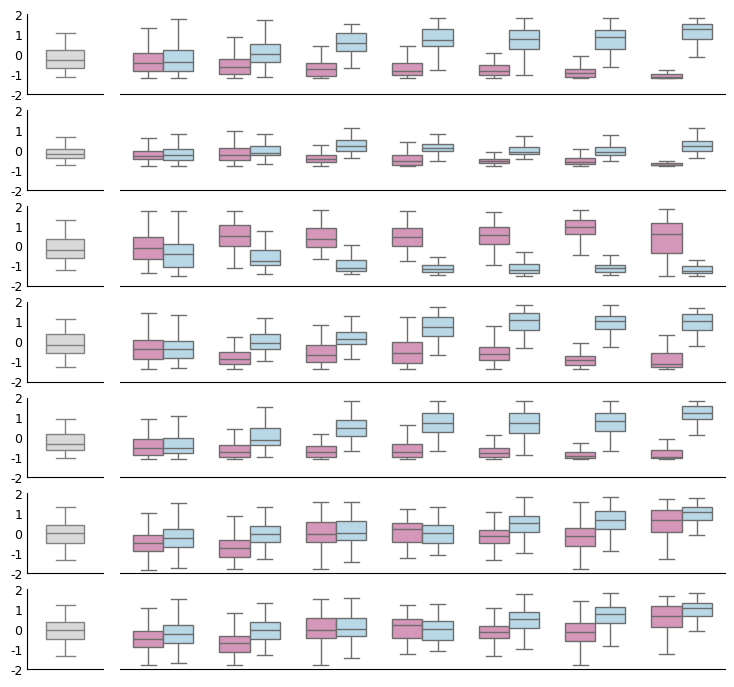

In [29]:
df_plot2 = df_behavior_norm.loc[df_behavior_norm['Generation']=="S1"]
df_plot = df_behavior_norm.loc[df_behavior_norm['Generation']!='S1'].sort_values(by=['Generation','Category'])
params = df_behavior_norm.loc[:,df_behavior_norm.columns.str.endswith('norm')].columns
params = params[~params.str.split('_').str[0].isin(['Velocity', 'TD'])].to_list()+params[params.str.split('_').str[0].isin(['Velocity', 'TD'])].to_list()

fig = plt.figure(figsize=(9,8.5))
gs = gridspec.GridSpec(len(params), 2, figure=fig, width_ratios=[1, 8],wspace=0.05)

for i,param in enumerate(params):
    
    ax0 = fig.add_subplot(gs[2*i])
    ax1 = fig.add_subplot(gs[2*i+1])
    upper_limit = df_plot[param].mean()+1.96*df_plot[param].std()
    lower_limit = df_plot[param].mean()-1.96*df_plot[param].std()
    

    sns.boxplot(x="Generation", y=param,hue='Category',
                data = df_plot.loc[(df_plot[param]>lower_limit)&(df_plot[param]<upper_limit)],
                ax=ax1, palette = ['#DE8CBB','#B0DAEF'],fliersize=0,width=0.7)
    
    
    upper_limit2 = df_plot2[param].mean()+1.96*df_plot2[param].std()
    lower_limit2 = df_plot2[param].mean()-1.96*df_plot2[param].std()
    sns.boxplot(x="Generation", y=param,
                data = df_plot2.loc[(df_plot2[param]>lower_limit2)&(df_plot2[param]<upper_limit2)],ax=ax0, 
                palette = ['#D9D9D9'],fliersize=0,width=0.5)

    ax0.set_yticks(np.arange(-2,3,1))
    ax0.set_yticklabels(labels = np.arange(-2,3,1).round(1),size=9)
    if param == 'DZTD_norm':
        param = 'TDDZ'
    #ax0.set_ylabel(param.split('_')[0],size=20)
    ax0.set_xlabel('')
    ax0.set_ylabel('')
    ax0.spines['top'].set_visible(False)
    ax0.spines['right'].set_visible(False)
    ax0.set_xticklabels('')
    ax0.set_yticklabels(np.arange(-2,3,1))
    ax0.tick_params(axis='both',width=0, length=0)
    
    ax1.set_yticks(np.arange(-2,3,1))
    ax1.set_yticklabels('')
    ax1.set_xticklabels('')
    ax1.tick_params(axis='both',width=0, length=0)
    ax1.set_ylabel('')
    ax1.set_xlabel('')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_visible(False)
    ax1.legend("",frameon=False, loc = [0, 0.9])

plt.show()